In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import load_model
from sklearn.metrics import confusion_matrix, classification_report

In [2]:
#load the best model saved during training
model = load_model('../models/best_model.keras')

#load test data
X_test = np.load('../data/X_test.npy')
y_test = np.load('../data/y_test.npy')

emotion_names = ['Angry', 'Disgust', 'Fear', 'Happy', 'Neutral', 'Sad', 'Surprise']

print("Model and data loaded successfully")
print(f"Test set size: {X_test.shape[0]} images")


Model and data loaded successfully
Test set size: 7178 images


In [3]:
#evaluate overall accuracy
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

Test Loss: 0.9575
Test Accuracy: 0.6619 (66.19%)


In [4]:
#Get predictions
y_pred = model.predict(X_test)

#convert from one-hot encoded to single class members
y_pred_classes = np.argmax(y_pred, axis=1)
y_test_classes = np.argmax(y_test, axis=1)

print("Predictions generated!")
print(f"Example - Actual: {emotion_names[y_test_classes[0]]}, Predicted: {emotion_names[y_pred_classes[0]]}")

225/225 ━━━━━━━━━━━━━━━━━━━━ 21s 93ms/step
Predictions generated!
Example - Actual: Sad, Predicted: Fear


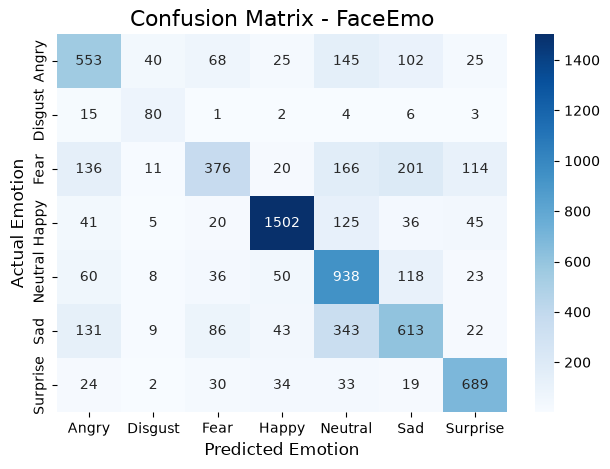

In [5]:
#Confusion Matrix

cm = confusion_matrix(y_test_classes, y_pred_classes)

#heatmap
plt.Figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=emotion_names, yticklabels=emotion_names)
plt.title('Confusion Matrix - FaceEmo', fontsize=16)
plt.ylabel('Actual Emotion', fontsize = 12)
plt.xlabel('Predicted Emotion', fontsize=12)
plt.tight_layout()
plt.savefig('../models/confusion_matrix.png')
plt.show()

In [6]:
#classification report
report = classification_report(y_test_classes, y_pred_classes, target_names=emotion_names)
print("Classification Report:")
print(report)

Classification Report:
              precision    recall  f1-score   support

       Angry       0.58      0.58      0.58       958
     Disgust       0.52      0.72      0.60       111
        Fear       0.61      0.37      0.46      1024
       Happy       0.90      0.85      0.87      1774
     Neutral       0.53      0.76      0.63      1233
         Sad       0.56      0.49      0.52      1247
    Surprise       0.75      0.83      0.79       831

    accuracy                           0.66      7178
   macro avg       0.63      0.66      0.64      7178
weighted avg       0.67      0.66      0.66      7178



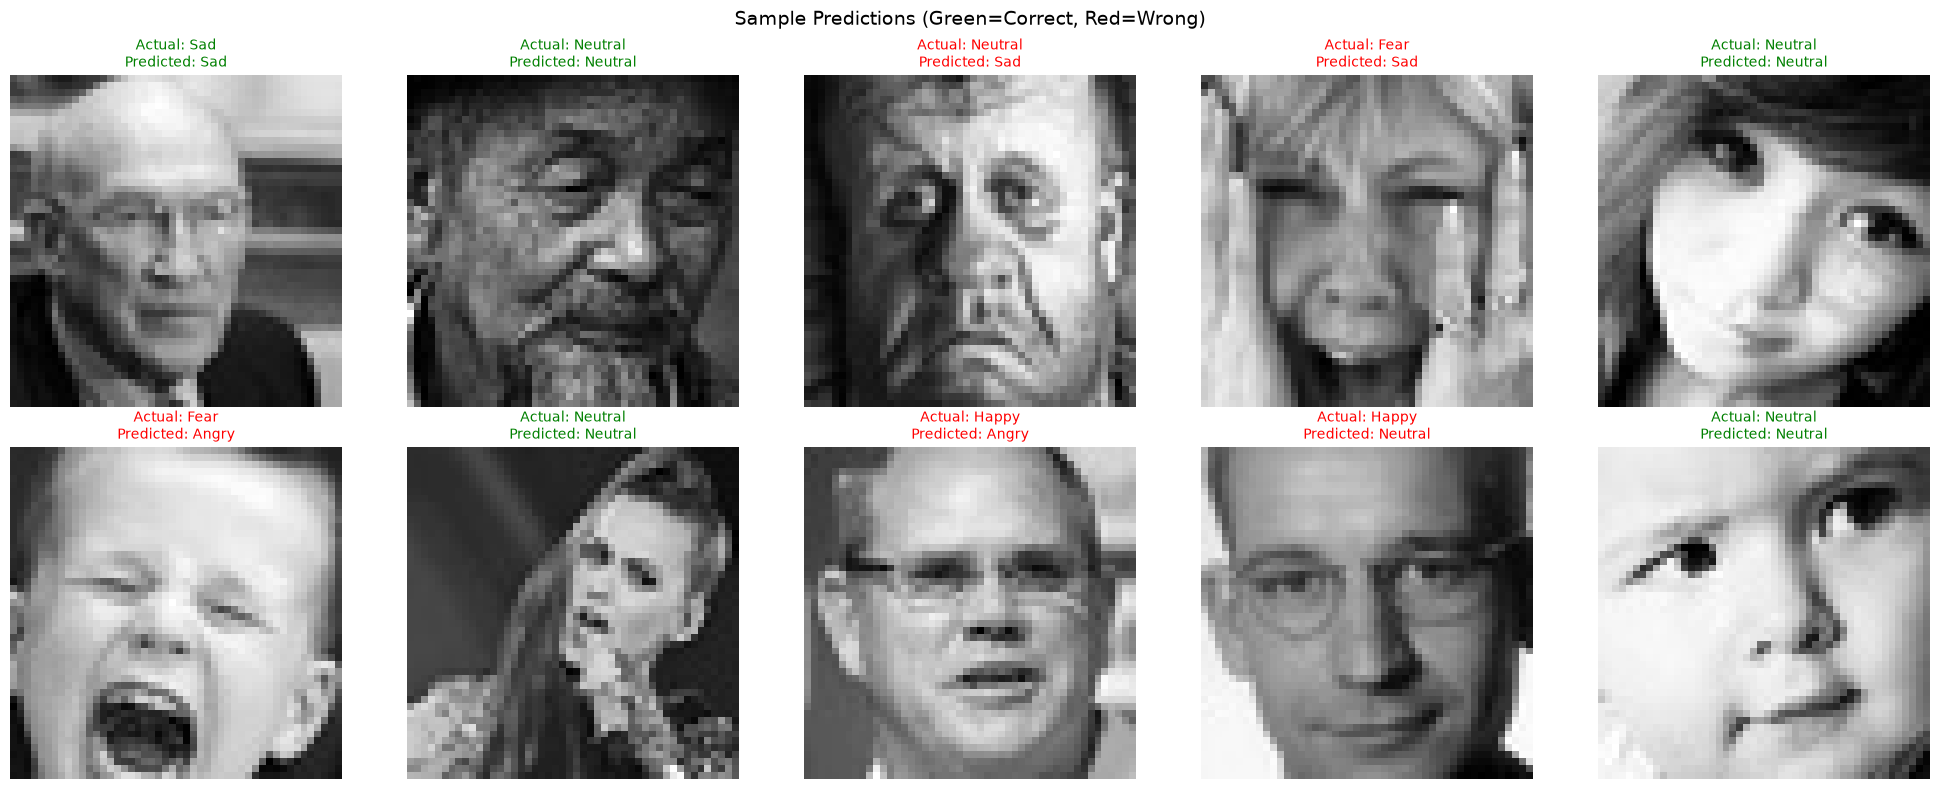

In [ ]:
# Show 10 random test images with actual vs predicted labels

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

random_indices = np.random.choice(len(X_test), 10, replace=False)

for i, idx in enumerate(random_indices):
    #show the image
    axes[i].imshow(X_test[idx].reshape(48, 48), cmap='gray')

    actual = emotion_names[y_test_classes[idx]]
    predicted = emotion_names[y_pred_classes[idx]]

    #green title if correct, red if wrong
    color = 'green' if actual == predicted else 'red'
    axes[i].set_title(f'Actual: {actual}\nPredicted: {predicted}',
                      color=color, fontsize = 10)
    axes[i].axis('off')

plt.suptitle('Sample Predictions (Green=Correct, Red=Wrong)', fontsize=14)
plt.tight_layout()
plt.savefig('../models/sample_predictions.png')
plt.show()